In [ ]:
# cell 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Draw AUC bar chart

In [ ]:
# cell 2
RESULTS_DIR = Path("..") / "Results" / "Model_selection"

files = {
    "Logistic Regression": RESULTS_DIR / "lr_cv_comparison.csv",
    "Classification Tree": RESULTS_DIR / "tree_cv_comparison.csv",
    "Random Forest": RESULTS_DIR / "rf_cv_comparison.csv",
    "XGBoost": RESULTS_DIR / "xgb_cv_comparison.csv",
}

In [ ]:
# cell 3
# Read CV result files

dfs = []

for model_name, file_path in files.items():
    df = pd.read_csv(file_path)
    df["model"] = model_name
    dfs.append(df)

cv = pd.concat(dfs, ignore_index=True)

In [ ]:
# cell 4
# Set display order and labels
outcome_order = ["mask", "protective", "social_avoidance"]

outcome_labels = {
    "mask": "Face mask",
    "protective": "General protective",
    "social_avoidance": "Social avoidance",
}

model_order = [
    "Logistic Regression",
    "Classification Tree",
    "Random Forest",
    "XGBoost",
]

cv["outcome"] = pd.Categorical(cv["outcome"], categories=outcome_order, ordered=True)
cv["model"] = pd.Categorical(cv["model"], categories=model_order, ordered=True)

cv = cv.sort_values(["outcome", "model"])

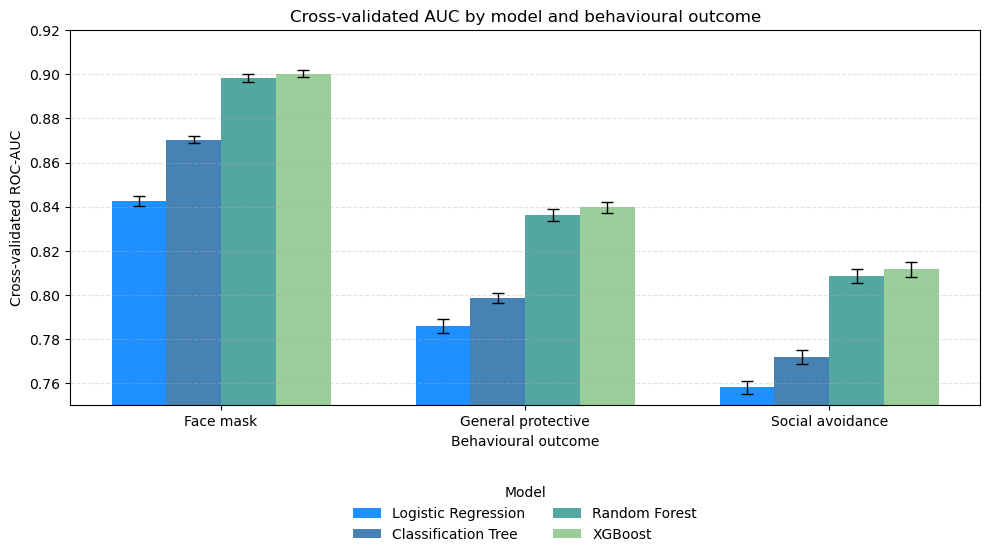

In [ ]:
# cell 5
# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(10, 5.8))

x = np.arange(len(outcome_order))
bar_width = 0.18

colors = {
    "Logistic Regression": "#1E90FF",
    "Classification Tree": "#4682B4",
    "Random Forest": "#54A6A0",
    "XGBoost": "#9ACD9A",
}

for i, model in enumerate(model_order):
    sub = cv[cv["model"] == model].set_index("outcome").loc[outcome_order]

    positions = x + (i - 1.5) * bar_width

    bars = ax.bar(
    positions,
    sub["roc_auc"],
    bar_width,
    yerr=sub["roc_auc_se"],
    capsize=4,
    label=model,
    color=colors[model],
    error_kw={
        "linewidth": 1,
        "capthick": 1
        }
    )

# Labels and style
ax.set_xticks(x)
ax.set_xticklabels([outcome_labels[o] for o in outcome_order])

ax.set_ylabel("Cross-validated ROC-AUC")
ax.set_xlabel("Behavioural outcome")
ax.set_title("Cross-validated AUC by model and behavioural outcome")
ax.set_xticks(x)
ax.set_xticklabels(["Face mask", "General protective", "Social avoidance"])

# Zoomed y-axis to make small differences visible
ax.set_ylim(0.75, 0.92)

ax.grid(axis="y", linestyle="--", alpha=0.35)

ax.legend(
    title="Model",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=False
)


plt.tight_layout()
plt.show()